<table style="width: 100%; border-collapse: collapse; border-bottom: 4px solid #003366;">
    <tr style="border: none;">
        <td style="border: none; text-align: left; vertical-align: middle; padding-bottom: 15px;">
            <h1 style="color: #003366; font-family: 'Helvetica', sans-serif; margin-top: 0; margin-bottom: 5px;">MAT1610: Cálculo I</h1>
            <h2 style="color: #555; margin-top: 10px; margin-bottom: 10px;">Laboratorio 03: Continuidad</h2>
        </td>
        <td style="border: none; text-align: right; vertical-align: middle; padding-bottom: 15px; width: 260px;">
            <img src="../source/FacMatematicas-15.png" alt="Logo UC" width="400" style="margin-bottom: 8px;"><br>
            <a href="https://colab.research.google.com/github/ManuelSanchezUribe/Laboratorios_MAT_UC/blob/main/MAT1610/Laboratorio_03/lab03.ipynb" target="_blank">
                <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab" width="120">
            </a>
        </td>
    </tr>
</table>

<br>
<div style="border: 1px solid #2980b9; border-left: 8px solid #2980b9; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2980b9; margin-top: 0;">Contexto y Referencias</h3>
    <p>Este laboratorio profundiza en la noción de <b>continuidad</b>, conectando los límites con el comportamiento local de las funciones, según el <b>Capítulo 2.5 de Stewart</b>. Analizaremos cuándo una "pequeña" variación en el dominio produce una "pequeña" variación en la imagen y cómo identificar diferentes tipos de rupturas.</p>
</div>

<table style="width: 100%; border-collapse: collapse; border: none;">
    <tr style="border: none;">
        <!-- Caja Izquierda: Contenidos -->
        <td style="width: 48%; border: 1px solid #27ae60; border-left: 8px solid #27ae60; padding: 15px; border-radius: 5px; vertical-align: top;">
            <h3 style="color: #27ae60; margin-top: 0;">Contenidos</h3>
            <ol style="margin-bottom: 0;">
                <li>Definición formal de continuidad en un punto.</li>
                <li>Clasificación de discontinuidades (Evitables, de Salto e Infinitas).</li>
                <li>Continuidad en intervalos y funciones compuestas.</li>
                <li>Teorema del Valor Intermedio (TVI).</li>
            </ol>
        </td>
        <td style="width: 4%; border: none; background: transparent;"></td>
        <td style="width: 48%; border: 1px solid #f39c12; border-left: 8px solid #f39c12; padding: 15px; border-radius: 5px; vertical-align: top;">
            <h3 style="color: #f39c12; margin-top: 0;">Objetivos de Aprendizaje</h3>
            <ul style="margin-bottom: 0;">
                <li>Implementar funciones definidas por tramos en Python.</li>
                <li>Visualizar e identificar gráficamente tipos de discontinuidad.</li>
                <li>Resolver problemas de parámetros para asegurar continuidad usando SymPy.</li>
                <li>Aplicar el TVI para localizar raíces de funciones continuas.</li>
            </ul>
        </td>
    </tr>
</table>


In [3]:
# importar librerias de la sesion
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from ipywidgets import interact, widgets

# Configuración para visualización matemática
sp.init_printing()
%matplotlib inline

# Configuración de estilo
try: plt.style.use('seaborn-v0_8-whitegrid') # Nombre nuevo (Matplotlib 3.6+)
except OSError: plt.style.use('seaborn-whitegrid') # Nombre antiguo
plt.rcParams['figure.figsize'] = (7, 4)

### 1. Definición de Continuidad
Según Stewart, una función $f$ es **continua en un número $a$** si se cumplen tres condiciones:
1. La función está definida: $f(a)$ existe ($a$ está en el dominio de $f$).
2. El límite existe: $\displaystyle \lim_{x \to a} f(x)$ existe (es decir, los límites laterales existen y son iguales $\displaystyle \lim_{x \to a^-} f(x) = \lim_{x \to a^+} f(x)$).
3. El límite es igual a la función definida en el punto: $\displaystyle \lim_{x \to a} f(x) = f(a)$.

Si $f$ no es continua en $a$, decimos que $f$ tiene una **discontinuidad** en dicho punto.

Intuitivamente, una función es continua si podemos dibujar su gráfica sin levantar el lápiz del papel. Matemáticamente, esto significa que pequeños cambios en $x$ producen pequeños cambios en $f(x)$.

### Ejemplo 1.1: Verificación Analítica con Python
Comprobemos analíticamente la continuidad de la función polinomial $f(x) = x^2 - 3x + 4$ en $x = 2$ utilizando Cálculo Simbólico (`SymPy`).

In [4]:
# Ejemplo 1.1: Verificación usando SymPy
x = sp.Symbol('x')
f = x**2 - 3*x + 4
a = 2

# Evaluamos y calculamos límite
f_a = f.subs(x, a)
lim_f = sp.limit(f, x, a)

print(f"Criterio 1: f({a}) = {f_a}")
print(f"Criterio 2: Limite = {lim_f}")
print(f"Criterio 3: ¿Límite == f(a)? -> {f_a == lim_f}")

# Criterio 3: Verificamos la igualdad
es_continua = (f_a == lim_f)
if es_continua:
    print("Conclusión: La función es continua en x = 2.")

Criterio 1: f(2) = 2
Criterio 2: Limite = 2
Criterio 3: ¿Límite == f(a)? -> True
Conclusión: La función es continua en x = 2.


### Ejemplo 1.2: Aplicación a la Ingeniería (Perfil Térmico)
En ingeniería de materiales, al unir dos barras de diferentes aleaciones en $x=0$, el perfil térmico debe ser continuo. Supongamos el modelo:
$$
T(x) = 
\begin{cases} 
50 \cos(x) & \text{si } x \leq 0 \\
A e^{-0.5x} & \text{si } x > 0 
\end{cases}
$$

Para que la distribución térmica sea físicamente válida, calculemos el valor de la constante $A$ que garantiza la continuidad en $x=0$.

In [5]:
# Ejemplo 1.2: Encontrar constante A
x, A = sp.symbols('x A')
T_izq = 50 * sp.cos(x)
T_der = A * sp.exp(-0.5*x)

# Calculamos límites laterales en x = 0
L_izq = sp.limit(T_izq, x, 0, dir='-')
L_der = sp.limit(T_der, x, 0, dir='+')

# Resolvemos la ecuación L_izq == L_der
ecuacion = sp.Eq(L_izq, L_der)
sol_A = sp.solve(ecuacion, A)[0]
print(f"El valor de A para que no haya salto térmico es: {sol_A}")

El valor de A para que no haya salto térmico es: 50


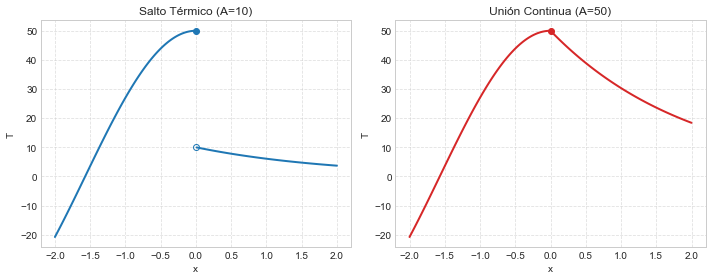

In [23]:
x = np.linspace(-2, 2, 200) 
A10 = 10.0
A50 = 50.0  

x_izq = x[x < 0]
x_der = x[x > 0]
T_izq = 50 * np.cos(x_izq)                 
T_der_A10 = A10 * np.exp(-0.5 * x_der)     
T_der_A50 = A50 * np.exp(-0.5 * x_der)     

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
# --- Gráfico 1: Función con discontinuidad (A = 10) ---
ax[0].plot(x_izq, T_izq, lw=2, color='C0')
ax[0].plot(x_der, T_der_A10, lw=2, color='C0')
ax[0].plot(0, 50, 'o', color='C0')                     
ax[0].plot(0, A10, 'o', fillstyle='none', color='C0')  

# Configuración visual del gráfico 1
ax[0].set_title('Salto Térmico (A=10)')
ax[0].set_xlabel('x')
ax[0].set_ylabel('T')
ax[0].grid(True, linestyle='--', alpha=0.6) # Cuadrícula sutil

# --- Gráfico 2: Función continua (A = 50) ---
ax[1].plot(x_izq, T_izq, lw=2, color='C3')
ax[1].plot(x_der, T_der_A50, lw=2, color='C3')
ax[1].plot(0, 50, 'o', color='C3')

# Configuración visual del gráfico 2
ax[1].set_title('Unión Continua (A=50)')
ax[1].set_xlabel('x')
ax[1].set_ylabel('T')
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() 
plt.show()

### Ejemplo 1.3: Continuidad en Puntos Angulosos (Valor Absoluto)
A veces existe la confusión de que una función con una esquina abrupta no es continua. En ingeniería de control y en aprendizaje de maquina, las funciones de error como el Error Absoluto son muy comunes. Analicemos $f(x) = |x - 3| + 2$ en $x = 3$.


Criterio 1: f(3) = 2
Criterio 2: Lím. Izq = 2 | Lím. Der = 2
Criterio 3: ¿Límites == f(a)? -> True


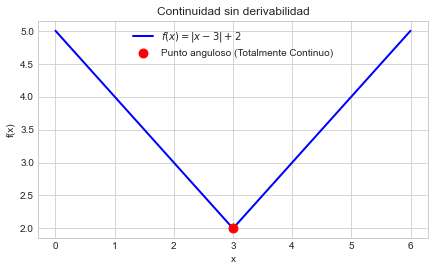

In [21]:
# Ejemplo 1.3: Continuidad en puntos angulosos
x = sp.Symbol('x')
f_abs = sp.Abs(x - 3) + 2
a = 3

# Evaluamos los tres criterios
lim_izq = sp.limit(f_abs, x, a, dir='-')
lim_der = sp.limit(f_abs, x, a, dir='+')
f_a = f_abs.subs(x, a)

print(f"Criterio 1: f(3) = {f_a}")
print(f"Criterio 2: Lím. Izq = {lim_izq} | Lím. Der = {lim_der}")
print(f"Criterio 3: ¿Límites == f(a)? -> {lim_izq == lim_der == f_a}")

# Visualización para mostrar la esquina continua
x_vals = np.linspace(0, 6, 200)
f_num = np.abs(x_vals - 3) + 2

plt.plot(x_vals, f_num, color='blue', lw=2, label='$f(x) = |x-3| + 2$')
plt.scatter([3], [2], color='red', zorder=5, s=80, label='Punto anguloso (Totalmente Continuo)')
plt.title('Continuidad sin derivabilidad')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()


# **2. Clasificación de Discontinuidades**

Cuando los criterios de continuidad fallan, la discontinuidad se clasifica en uno de tres tipos:

1. **Discontinuidad Evitable (Removible):** El límite $\lim_{x \to a} f(x)$ existe, pero $f(a)$ es distinto o indefinido. (Un "agujero").
2. **Discontinuidad de Salto:** Los límites laterales existen y son finitos, pero son diferentes. (Un "escalón").
3. **Discontinuidad Infinita:** Al menos uno de los límites laterales tiende a $+\infty$ o $-\infty$. (Una "asíntota vertical").

### Ejemplo 2.1: Discontinuidad Evitable
Analicemos la función de señales $f(x) = \frac{\sin(x)}{x}$ en $x=0$.

El límite de sin(x)/x cuando x->0 es: 1
Al existir el límite (es 1), la discontinuidad es EVITABLE. Se arregla definiendo f(0) = 1.



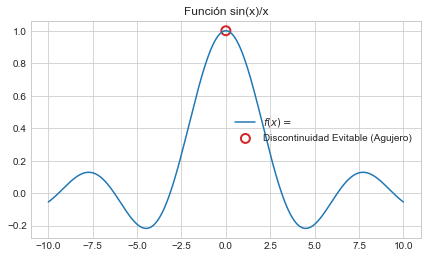

In [26]:
# Ejemplo 2.1: Discontinuidad evitable
x = sp.Symbol('x')
f_sinc = sp.sin(x)/x

# Evaluamos en 0 y calculamos el límite
limite_sinc = sp.limit(f_sinc, x, 0)
print(f"El límite de sin(x)/x cuando x->0 es: {limite_sinc}")
print("Al existir el límite (es 1), la discontinuidad es EVITABLE. Se arregla definiendo f(0) = 1.\n")

# Visualización
x_vals = np.linspace(-10, 10, 400)
f_vals = np.where(x_vals==0, np.nan, np.sin(x_vals)/x_vals) # np.where evita el warning division by zero

plt.plot(x_vals, f_vals, color='C00', label='$f(x) = \frac{\sin(x)}{x}$')
plt.scatter([0], [1], facecolors='none', edgecolors='C03', s=80, lw=2, label='Discontinuidad Evitable (Agujero)')
plt.title('Función sin(x)/x')
plt.legend()
plt.show()


### Ejemplo 2.2: Discontinuidad de Salto (Circuito)
La función de Heaviside o Escalón Unitario se usa para modelar el encendido de un circuito.
$$H(t) = \begin{cases} 0 & t < 0 \\ 1 & t \geq 0 \end{cases}$$

Límite Izquierdo: 0
Límite Derecho: 1
Son distintos y finitos -> Discontinuidad de SALTO.



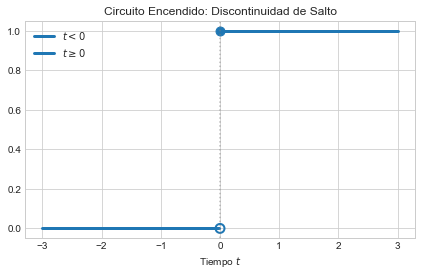

In [28]:
# Ejemplo 2.2: Discontinuidad de salto
t = sp.Symbol('t')
H = sp.Heaviside(t)

lim_izq = sp.limit(H, t, 0, dir='-')
lim_der = sp.limit(H, t, 0, dir='+')

print(f"Límite Izquierdo: {lim_izq}")
print(f"Límite Derecho: {lim_der}")
print("Son distintos y finitos -> Discontinuidad de SALTO.\n")

# Gráfico
t_izq = np.linspace(-3, -0.01, 100)
t_der = np.linspace(0, 3, 100)

plt.plot(t_izq, np.zeros_like(t_izq), color='C00', lw=3, label='$t < 0$')
plt.plot(t_der, np.ones_like(t_der), color='C00', lw=3, label='$t \geq 0$')
plt.scatter([0], [0], facecolors='none', edgecolors='C00', s=80, lw=2) # Agujero (no incluido)
plt.scatter([0], [1], color='C00', s=80) # Punto relleno (incluido)
plt.axvline(0, color='gray', linestyle=':', alpha=0.5)

plt.title("Circuito Encendido: Discontinuidad de Salto")
plt.xlabel("Tiempo $t$")
plt.legend()
plt.show()


### Ejemplo 2.3: Discontinuidad Infinita (Resonancia Mecánica)
Si un sistema vibratorio es forzado con una frecuencia $\omega$ cercana a su frecuencia natural (ej. $\omega_0 = 5$), la amplitud a menudo sigue la forma:
$$A(\omega) = \frac{1}{\omega^2 - 25}$$


Límite de la amplitud al acercarse a 5 rad/s: oo
El límite es infinito -> Discontinuidad INFINITA.



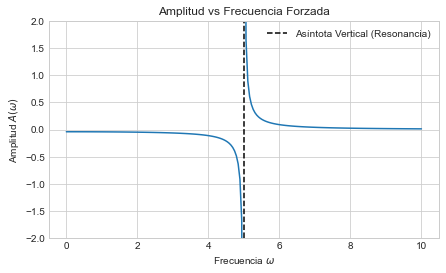

In [30]:
# Ejemplo 2.3: Discontinuidad Infinita
w = sp.Symbol('w')
A = 1 / (w**2 - 25)

# Calculamos límite al acercarse a la frecuencia natural (w -> 5 por la derecha)
lim_w5 = sp.limit(A, w, 5, dir='+')
print(f"Límite de la amplitud al acercarse a 5 rad/s: {lim_w5}")
print("El límite es infinito -> Discontinuidad INFINITA.\n")

# Gráfico
w_vals1 = np.linspace(0, 4.99, 100)
w_vals2 = np.linspace(5.01, 10, 100)

plt.plot(w_vals1, 1/(w_vals1**2 - 25), color='C00')
plt.plot(w_vals2, 1/(w_vals2**2 - 25), color='C00')
plt.axvline(5, color='black', linestyle='--', label='Asíntota Vertical (Resonancia)')

plt.ylim(-2, 2)
plt.title("Amplitud vs Frecuencia Forzada")
plt.xlabel("Frecuencia $\omega$")
plt.ylabel("Amplitud $A(\omega)$")
plt.legend()
plt.show()


# **3. Continuidad en Intervalos y Funciones Compuestas**

- Una función es continua en un intervalo abierto $(a, b)$ si es continua en cada punto del intervalo.
- Para un intervalo cerrado $[a, b]$, también se exige continuidad lateral en los extremos: $\displaystyle \lim_{x \to a^+} f(x) = f(a)$ y $\displaystyle \lim_{x \to b^-} f(x) = f(b)$.

**Funciones Compuestas:** Si una señal es $g(x)$ y pasa por un sensor $f(x)$, la lectura es $(f \circ g)(x) = f(g(x))$. Si $g$ es continua en $a$ y $f$ es continua en $g(a)$, ¡la composición completa es continua!

### Ejemplo 3.1: Continuidad en el extremo de un intervalo
Consideremos la semiesfera de tensión geométrica $y = \sqrt{9 - x^2}$ en el intervalo $[-3, 3]$. Evaluemos la continuidad en el extremo derecho $x = 3$.

Límite lateral al aproximarse a x=3: 0
Evaluación y(3): 0
Al coincidir, la función es continua por la izquierda en x=3.


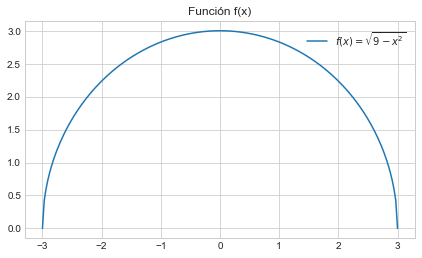

In [34]:
# Ejemplo 3.1: Límite lateral en extremo cerrado
x = sp.Symbol('x')
y = sp.sqrt(9 - x**2)

# Límite por la izquierda (acercándonos desde dentro del intervalo)
lim_izq = sp.limit(y, x, 3, dir='-')
evaluacion = y.subs(x, 3)

print(f"Límite lateral al aproximarse a x=3: {lim_izq}")
print(f"Evaluación y(3): {evaluacion}")
print("Al coincidir, la función es continua por la izquierda en x=3.")

# Visualización
x_vals = np.linspace(-3, 3, 200)
f_vals = np.sqrt(9-x_vals**2)
plt.plot(x_vals, f_vals, color='C00', label='$f(x) = \sqrt{9-x^2}$')
plt.title('Función f(x)')
plt.legend()
plt.show()


### Ejemplo 3.2: Función Compuesta
Evaluemos analíticamente el dominio de continuidad para $h(x) = e^{\sin(x)}$. Dado que $\sin(x)$ es continua en todo $\mathbb{R}$ y $e^x$ es continua en $\mathbb{R}$, $h(x)$ debería serlo.

Límite en pi: 1 | h(pi): 1


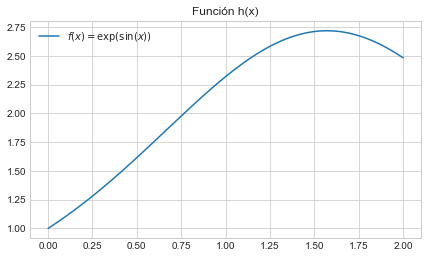

In [37]:
# Ejemplo 3.2: Comprobación simple
x = sp.Symbol('x')
h = sp.exp(sp.sin(x))

# Evaluamos un punto arbitrario como x = pi
limite_pi = sp.limit(h, x, sp.pi)
eval_pi = h.subs(x, sp.pi)

print(f"Límite en pi: {limite_pi} | h(pi): {eval_pi}")

# Visualización
x_vals = np.linspace(0, 2, 400)
f_vals = np.exp(np.sin(x_vals))
plt.plot(x_vals, f_vals, color='C00', label='$f(x) = \exp(\sin(x))$')
plt.title('Función h(x)')
plt.legend()
plt.show()


# **4. Teorema del Valor Intermedio (TVI)**

El **Teorema del Valor Intermedio** garantiza que si una función $f$ es continua en un intervalo cerrado $[a, b]$, toma todos los valores intermedios entre $f(a)$ y $f(b)$.

Si un auto acelera de $0$ a $100 \text{ km/h}$, el TVI garantiza que en algún instante su velocidad fue de exactamente $65 \text{ km/h}$. Lo utilizaremos frecuentemente para garantizar que una ecuación tiene una raíz (cuando pasa de valores negativos a positivos, cruza obligatoriamente por el 0).

### Ejemplo 4.1: Analítica de Raíces
Demostremos que el polinomio de diseño $f(x) = x^3 - 3x + 1$ tiene una raíz real entre $[0, 1]$.

In [55]:
# Ejemplo 4.1: Aplicando el TVI
x = sp.Symbol('x')
f = x**3 - 3*x + 1

f_0 = f.subs(x, 0)
f_1 = f.subs(x, 1)

print(f"En x=0, f(0) = {f_0}")
print(f"En x=1, f(1) = {f_1}")
print("Al ser f(x) un polinomio continuo y cambiar de signo (+ a -), el TVI garantiza una raíz (f(c)=0) en (0, 1).")



En x=0, f(0) = 1
En x=1, f(1) = -1
Al ser f(x) un polinomio continuo y cambiar de signo (+ a -), el TVI garantiza una raíz (f(c)=0) en (0, 1).


### Visualizando el TVI
Tracemos la gráfica para confirmar visualmente el cruce del eje $x$ predicho por el teorema.

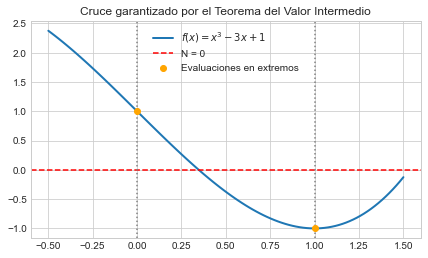

In [56]:
# Ejemplo 4.2: Visualización
x_vals = np.linspace(-0.5, 1.5, 100)
f_vals = x_vals**3 - 3*x_vals + 1

plt.plot(x_vals, f_vals, label='$f(x) = x^3 - 3x + 1$', color='C00', lw=2)
plt.axhline(0, color='red', linestyle='--', label='N = 0')
plt.axvline(0, color='gray', linestyle=':')
plt.axvline(1, color='gray', linestyle=':')
plt.scatter([0, 1], [1, -1], color='orange', zorder=5, label='Evaluaciones en extremos')

plt.title('Cruce garantizado por el Teorema del Valor Intermedio')
plt.legend()
plt.show()


<div class="alert alert-block alert-success" style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;"> 
    <h2 style="color: #2e7d32; margin-top: 0;">🏁 Ticket de Salida</h2>
    <p style="font-size: 1.1em; color: #1b5e20;"><strong>¡Felicidades!</strong> Ha completado la parte teórica del laboratorio. Es hora de poner a prueba su capacidad para analizar la continuidad empleando Python en los siguientes problemas de modelación.</p>
    <h3 style="color: #2e7d32; margin-top: 15px;">💻 Ejercicios: </h3>
</div>


### Ejercicio 1: Optimización de Materiales (Continuidad Paramétrica)
Una viga de soporte está sometida a dos tipos de cargas diferentes. El momento flector a lo largo de su eje longitudinal $x$ está modelado por la siguiente función a trozos:
$$M(x) = \begin{cases} c x^2 + 2x & \text{si } x \leq 2 \\ x^3 - cx & \text{si } x > 2 \end{cases}$$
1. Encuentre, utilizando los límites laterales en `SymPy`, el valor de la constante $c$ que garantiza que el momento flector $M(x)$ sea **continuo** en $x=2$ (evitando una fractura teórica).
2. Grafique ambas funciones en sus respectivos dominios ($x \in [0, 4]$) utilizando el valor de $c$ encontrado.
---


In [57]:
# Escriba su código aquí


### Ejercicio 2: Localización de Raíces (TVI)
El **Teorema del Valor Intermedio** establece que si $f$ es continua en $[a, b]$ y $N$ es un número entre $f(a)$ y $f(b)$, existe al menos un $c \in (a, b)$ tal que $f(c) = N$.

**Misión:** Demuestre gráficamente que la función $f(x) = \cos(x) - x$ tiene una raíz en el intervalo $[0, 1]$. Use el Teorema para acercarnos a la solución con una precisión de 3 dígitos.

---

In [58]:
# Escriba su código aquí

### Ejercicio 3: Diagnóstico de Sistemas Racionales
Se le entrega el siguiente modelo de ganancia de un sistema de telecomunicaciones:
$$G(s) = \frac{s^2 - 4}{s^2 - s - 2}$$
1. Encuentre todos los puntos $s$ donde el modelo presenta posibles discontinuidades calculando las raíces del denominador (use `sp.solve()`).
2. Calcule los límites en cada punto problemático para **clasificar** la discontinuidad en cada uno de esos puntos (indique si es Evitable, de Salto o Infinita).
---


In [ ]:
# Escriba su código aquí

### Ejercicio 3: Enfriamiento Abrupto
Un horno industrial se apaga a los 10 minutos para un proceso de templado. El modelo del calor latente $C(t)$ es:
$$C(t) = \begin{cases} 100 - t^2 & \text{si } 0 \leq t < 10 \\ \frac{500}{t} & \text{si } t \geq 10 \end{cases}$$
1. Compruebe mediante los tres criterios formales (o límites laterales) si la función presenta una discontinuidad en $t = 10$.
2. De ser discontinua, clasifíquela y calcule matemáticamente el tamaño de la caída o "salto" de temperatura instantánea.
---


In [59]:
# Escriba su código aquí

### Ejercicio 5: Evitación de Colisiones usando el TVI (Tema 4)
Dos drones vuelan en líneas verticales. La altura del Drone 1 es $h_1(t) = t^2 + 1$ y la del Drone 2 es $h_2(t) = \cos(\pi t) + 3$ (en metros y $t$ en segundos).
1. Defina una función de "diferencia de alturas" $D(t) = h_1(t) - h_2(t)$.
2. Evaluando $D(1)$ y $D(2)$, use código para demostrar bajo el TVI si existe la certeza de que ambos drones cruzaron la misma altitud (potencial colisión) entre $t=1$ y $t=2$.

---

In [ ]:
# Escriba su código aquí

<div style="width: 100%; border-top: 2px solid #ddd; padding-top: 15px; margin-top: 30px; font-family: sans-serif; font-size: 0.85em; color: #666;">
    <p>
        <strong>© 2026 Manuel A. Sánchez </strong><br>
        <a href="https://www.mat.uc.cl/" style="color: #003366; text-decoration: none;">Facultad de Matemáticas</a><br>
        Pontificia Universidad Católica de Chile
    </p>
    <p>
        <i>Este material está diseñado para el curso MAT1610 y no debe ser redistribuido sin permiso explícito.</i>
    </p>
</div>